In this file I'll be writing experiment-runner classes

NEXT UP: WRITE OUT VERBOSE LEVELS

In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager
from src.evaluation import Evaluator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1


config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )       
data_orchestrator = DataOrchestrator(config).build()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.configmanagement.experimentconfigmanager import ExperimentRunner

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


# Usage:
runner = (ExperimentRunner(data_orchestrator, verbose = 0)
    .add_baseline_model('PersistenceModel', 'persistence')
    .add_baseline_model('ClimateologyModel', 'climateology')    
    .add_shallow_model('NodeRFModel', 'node_rf', model_hparams={'n_estimators': 100})
    .add_gnn('SpatialGNNModel', 'gcn-identity_graph',    'identity_graph',                 global_hparams=global_hparams)
    .add_gnn('SpatialGNNModel', 'gcn-mesh_graph',        'mesh_graph',                     global_hparams=global_hparams)        
    .add_gnn('SpatialGNNModel', 'gcn-commuter14_2',      'static_commuter14_2',            global_hparams=global_hparams)        
    .add_gnn('SpatialGNNModel', 'gcn-commuter24_2',      'static_commuter24_2',            global_hparams=global_hparams)                      
    .add_gnn('SpatialGNNModel', 'gcn-dynamic_commuter2', 'dynamic_commuter2','dynamic', data_kwargs={'timesteps': range(2006,2021)} , global_hparams=global_hparams)                     
    # GATVs
    .add_gnn('GATv2Model',      'gatv2-identity_graph', 'identity_graph',                 global_hparams=global_hparams)
    .add_gnn('GATv2Model',      'gatv2-mesh_graph',     'mesh_graph',                     global_hparams=global_hparams)    
    .add_gnn('GATv2Model',      'gatv2-commuter14_2',   'static_commuter14_2',                     global_hparams=global_hparams)    
    .add_gnn('GATv2Model',      'gatv2-commuter24_2',   'static_commuter24_2',                     global_hparams=global_hparams)        
    .add_gnn('GATv2Model',      'gatv2-dynamic_commuter2',     'dynamic_commuter2', data_kwargs={'timesteps': range(2006,2021)} , global_hparams=global_hparams)                     
)

results = runner.run()

==                 persistence                  ==
==                 climateology                 ==
==                   node_rf                    ==
==              gcn-identity_graph              ==


Training epochs:  37%|████████████████████████████████████████████████████████▎                                                                                                | 92/250 [19:42<33:51, 12.86s/it]

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5675


AttributeError: 'SpatialGNNModel' object has no attribute '_return_model_trained_print'

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


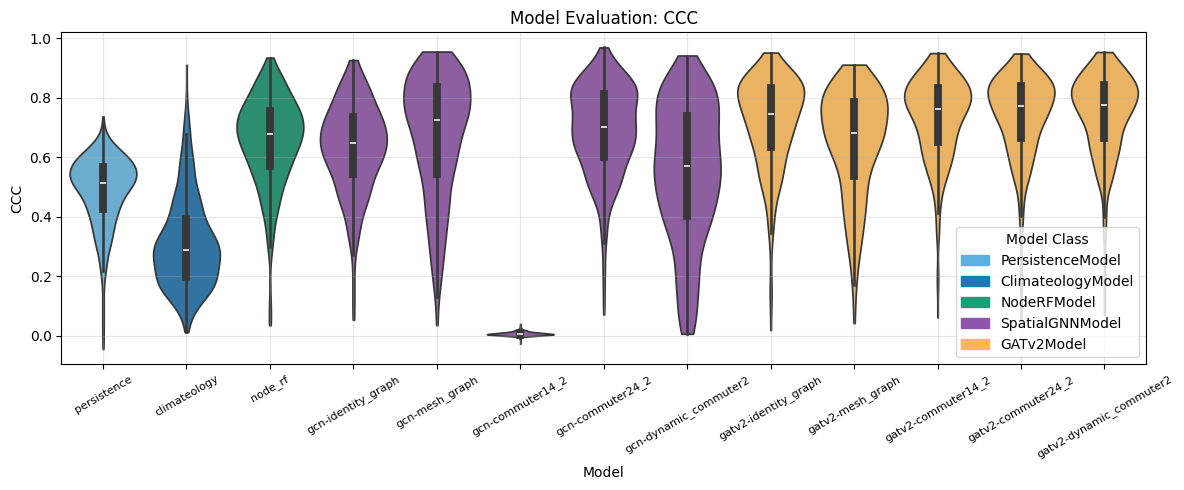

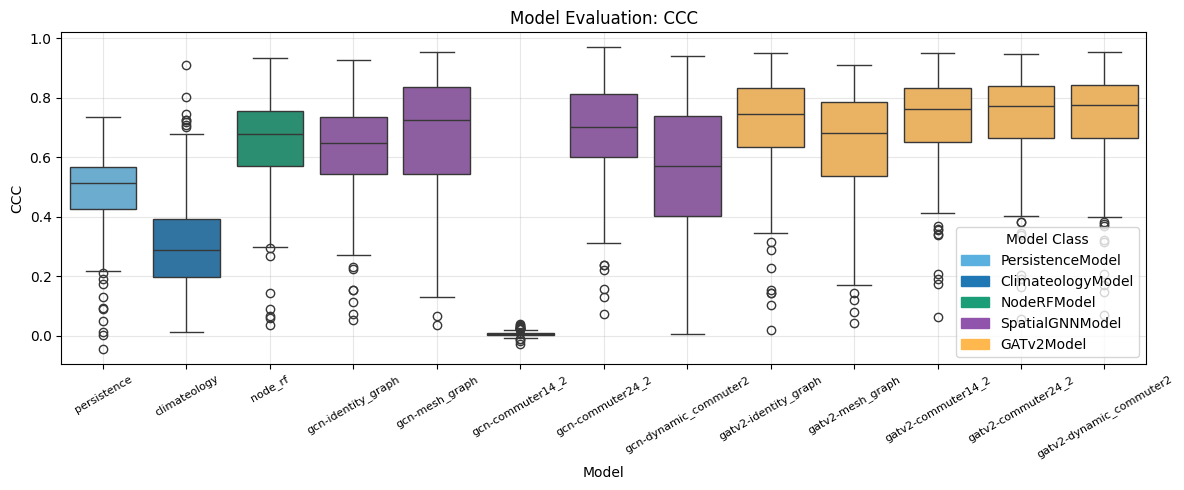

In [ ]:
runner.evaluation.plotter.plot_metric('ccc', horizon='horizon_0', plot_type = 'violin')
runner.evaluation.plotter.plot_metric('ccc', horizon='horizon_0', plot_type = 'box')